# Sentiment Analysiz and Sentiment Modeling
## About Dataset:
#### This dataset contains conversations between users and experienced psychologists related to mental health topics. Carefully collected and anonymized, the data can be used to further the development of Natural Language Processing (NLP) models which focus on providing mental health advice and guidance. It consists of a variety of questions which will help train NLP models to provide users with appropriate advice in response to their queries. 


#### This dataset contains conversations between users and experienced psychologists about important mental health topics

#### Context: The conversation between the user and the psychologist. (Text)
#### Response: The response from the psychologist to the user. (Text)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from textblob import Word, TextBlob
from wordcloud import WordCloud
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.optim import AdamW
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...


In [4]:
print(df.shape)

(3512, 2)


In [5]:
df.describe(include='object')

,Context,Response
count,3512,3508
unique,995,2479
top,I have so many issues to address. I have a his...,The fact that you're reaching out for help her...
freq,94,3


In [6]:
# random responce:

random_response = df["Response"][1:2]
print("before text preprocessing len: ", len(df["Response"][1]))

before text preprocessing len:  2082


In [7]:
# Normalizing Case Folding
df["Context"] = df["Context"].str.lower()
df["Response"] = df["Response"].str.lower()

In [8]:
# Remove punctuation
df["Context"] = df["Context"].str.replace(r"[^\w\s]", "", regex=True)
df["Response"] = df["Response"].str.replace(r"[^\w\s]", "", regex=True)

# Remove extra spaces
df["Context"] = df["Context"].str.replace(r"\s+", " ", regex=True).str.strip()
df["Response"] = df["Response"].str.replace(r"\s+", " ", regex=True).str.strip()

In [9]:
# Remove Stopwords (a, an, and, as, at, but, by, for, if, is, it, on, of, or, s, that, their, the, then, these ...)
sw = stopwords.words('english')

df["Context"] = df["Context"].apply(lambda x: " ".join(x for x in str(x).split() if x not in sw))
df["Response"] = df["Response"].apply(lambda x: " ".join(x for x in str(x).split() if x not in sw))

In [10]:
print("after text preprocessing len: ",len(df["Response"][1]))

after text preprocessing len:  1192


In [11]:
 #Let's remove words used less than 1
temp_Context = pd.Series(' '.join(df['Context']).split()).value_counts()
drops = temp_Context[temp_Context <= 1]
df['Context'] = df['Context'].apply(lambda x: " ".join(x for x in x.split() if x not in drops))

temp_Response = pd.Series(' '.join(df['Response']).split()).value_counts()
drops = temp_Response[temp_Response <= 1]
df['Response'] = df['Response'].apply(lambda x: " ".join(x for x in x.split() if x not in drops))

In [12]:
import re

# extracts word characters
tokenize_simple = lambda text: re.findall(r"\b\w+\b", str(text))

df['Context_tokens'] = df['Context'].fillna('').astype(str).apply(tokenize_simple)
df['Response_tokens'] = df['Response'].fillna('').astype(str).apply(tokenize_simple)

print(df[['Context_tokens', 'Response_tokens']].head(1))

                                      Context_tokens  \
0  [im, going, things, feelings, barely, sleep, n...   

                                     Response_tokens  
0  [everyone, thinks, youre, worthless, maybe, ne...  


In [13]:
# Lemmatization
df["Context"] = df["Context"].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))
df["Response"] = df["Response"].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))

In [14]:
print("after tokenizateion and lemmatization len: ",len(df["Response"][1]))

after tokenizateion and lemmatization len:  1135


In [15]:
df[["Context", "Response"]].head()

,Context,Response
0,im going thing feeling barely sleep nothing th...,everyone think youre worthless maybe need find...
1,im going thing feeling barely sleep nothing th...,hello thank question seeking advice feeling wo...
2,im going thing feeling barely sleep nothing th...,first thing id suggest getting sleep need impa...
3,im going thing feeling barely sleep nothing th...,therapy essential feeling depressed worthless ...
4,im going thing feeling barely sleep nothing th...,first want let know alone feeling always someo...


In [16]:
# Calculating term frequencies:
tf_Context = (
    df["Context"]
    .str.split(expand=False)
    .explode()
    .value_counts()
    .reset_index()
)

tf_Context.columns = ["Word", "Frequency"]

tf_Context.head(10)

,Word,Frequency
0,im,2164
1,feel,1331
2,dont,1188
3,like,1175
4,know,1009
5,get,991
6,want,980
7,ive,862
8,year,857
9,time,842


In [17]:
tf_Response = df["Response"].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis=0).reset_index()
tf_Response.columns = ["words", "tf"]
tf_Response.sort_values("tf", ascending=False)

,words,tf
10,feel,3051.0
51,may,2900.0
109,help,2536.0
46,relationship,2376.0
323,would,2353.0
...,...,...
12237,counselingi,2.0
12236,stumbling,2.0
12235,conditionsthe,2.0
12229,offending,2.0


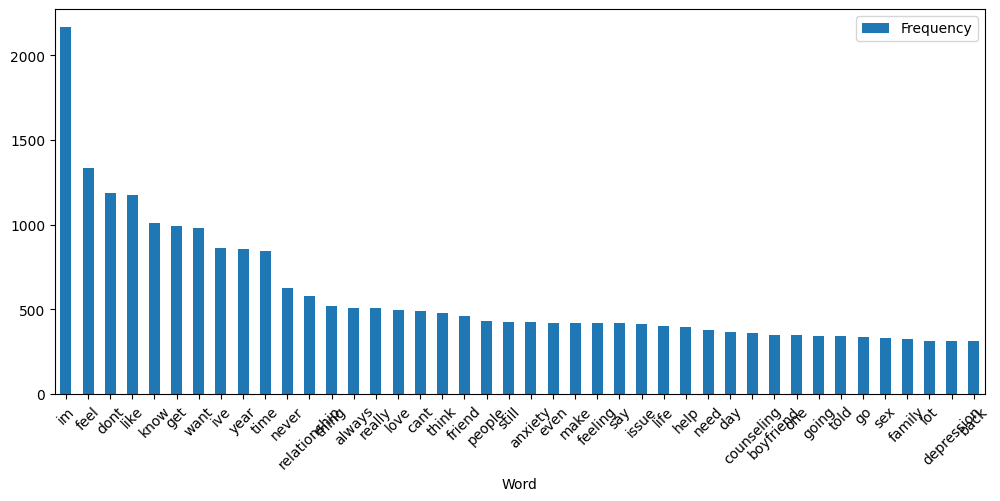

In [18]:
tf_Context[tf_Context["Frequency"] > 300].plot.bar(
    x="Word",
    y="Frequency",
    figsize=(12,5)
)

plt.xticks(rotation=45)
plt.show()

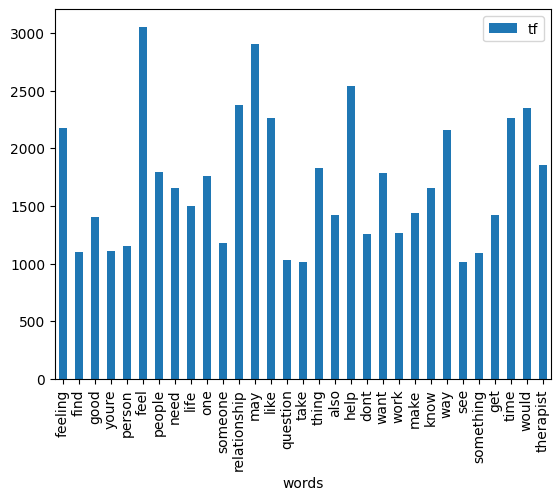

In [19]:
# Barplot for Response

tf_Response[tf_Response["tf"] > 1000].plot.bar(x="words", y="tf")
plt.show()

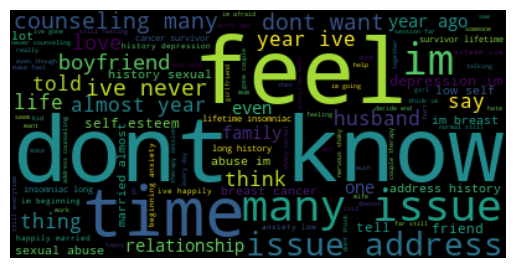

In [20]:
# Wordcloud for Context
text_Context = " ".join(i for i in df.Context)

wordcloud = WordCloud().generate(text_Context)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

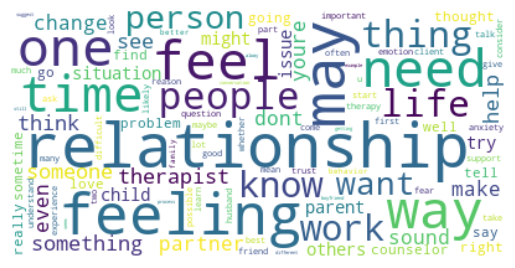

In [21]:
# Wordcloud for Response
text_Response = " ".join(i for i in df.Response)

wordcloud_Response = WordCloud(max_font_size=50,
                      max_words=100,
                      background_color="white").generate(text_Response)
plt.figure()
plt.imshow(wordcloud_Response, interpolation="bilinear")
plt.axis("off")
plt.show()

In [22]:
sia = SentimentIntensityAnalyzer() 

In [23]:
df["polarity_score_Context"] = df["Context"].apply(lambda x: sia.polarity_scores(x)["compound"])
df["polarity_score_Context"]

0       0.8556
1       0.8556
2       0.8556
3       0.8556
4       0.8556
         ...  
3507   -0.4939
3508   -0.3818
3509   -0.9169
3510   -0.9346
3511   -0.8591
Name: polarity_score_Context, Length: 3512, dtype: float64

In [24]:
df["polarity_score_Response"] = df["Response"].apply(lambda x: sia.polarity_scores(x)["compound"])
df["polarity_score_Response"]

0       0.8020
1       0.9647
2       0.7964
3      -0.5116
4       0.4588
         ...  
3507   -0.9218
3508   -0.7579
3509    0.9801
3510    0.8625
3511   -0.1280
Name: polarity_score_Response, Length: 3512, dtype: float64

In [25]:
df["sentiment_label_Context"] = df["Context"].apply(lambda x: "pos" if sia.polarity_scores(x)["compound"] > 0 else "neg")

In [26]:
df["sentiment_label_Context"].value_counts()

sentiment_label_Context
neg    2431
pos    1081
Name: count, dtype: int64

In [27]:
df["sentiment_label_Response"] = df["Response"].apply(lambda x: "pos" if sia.polarity_scores(x)["compound"] > 0 else "neg")

df.columns

Index(['Context', 'Response', 'Context_tokens', 'Response_tokens',
       'polarity_score_Context', 'polarity_score_Response',
       'sentiment_label_Context', 'sentiment_label_Response'],
      dtype='object')

In [28]:
df[['polarity_score_Context', 'polarity_score_Response', 
    'sentiment_label_Context', 'sentiment_label_Response']]

,polarity_score_Context,polarity_score_Response,sentiment_label_Context,sentiment_label_Response
0,0.8556,0.8020,pos,pos
1,0.8556,0.9647,pos,pos
2,0.8556,0.7964,pos,pos
3,0.8556,-0.5116,pos,neg
4,0.8556,0.4588,pos,pos
...,...,...,...,...
3507,-0.4939,-0.9218,neg,neg
3508,-0.3818,-0.7579,neg,neg
3509,-0.9169,0.9801,neg,pos
3510,-0.9346,0.8625,neg,pos


In [29]:
df["sentiment_label_Response"].value_counts() 

sentiment_label_Response
pos    2863
neg     649
Name: count, dtype: int64

In [30]:
df["sentiment_label_Context"] = LabelEncoder().fit_transform(df["sentiment_label_Context"])
df["sentiment_label_Response"] = LabelEncoder().fit_transform(df["sentiment_label_Response"])

In [31]:
y = df["sentiment_label_Response"] # target, dependent variable
X = df["Response"] # independent variable


In [32]:
vectorizer = CountVectorizer()
X_countvector = vectorizer.fit_transform(X)

In [33]:
first5_words = vectorizer.get_feature_names_out()[:5]

word_frequencies = X_countvector.toarray()

for i, word in enumerate(first5_words):
    print(f"{word}: {word_frequencies[:, i]}")

05mg: [0 0 0 ... 0 0 0]
0r: [0 0 0 ... 0 0 0]
10: [0 0 0 ... 0 0 0]
100: [0 0 0 ... 0 0 0]
1000: [0 0 0 ... 0 0 0]


In [34]:
tf_idf_word_vectorizer = TfidfVectorizer()
X_tf_idf_word = tf_idf_word_vectorizer.fit_transform(X)
X_tf_idf_word

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 229804 stored elements and shape (3512, 12217)>

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_tf_idf_word , y, test_size=0.33, random_state=1)

              precision    recall  f1-score   support

           0       0.96      0.21      0.34       214
           1       0.85      1.00      0.92       945

    accuracy                           0.85      1159
   macro avg       0.90      0.60      0.63      1159
weighted avg       0.87      0.85      0.81      1159



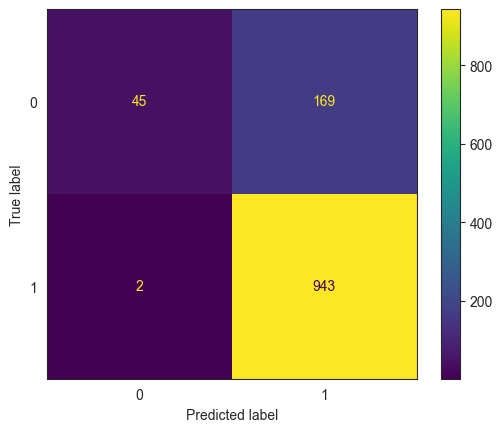

In [36]:
lr = LogisticRegression()
sns.set_style('white')
pipe_lr = make_pipeline(lr)
pipe_lr.fit(X_train,y_train)
pred = pipe_lr.predict(X_test)
print(classification_report(y_test,pred))
ConfusionMatrixDisplay(confusion_matrix(y_test,pred)).plot()
score_lr = accuracy_score(y_test,pred)

              precision    recall  f1-score   support

           0       0.87      0.73      0.79       214
           1       0.94      0.98      0.96       945

    accuracy                           0.93      1159
   macro avg       0.91      0.85      0.88      1159
weighted avg       0.93      0.93      0.93      1159



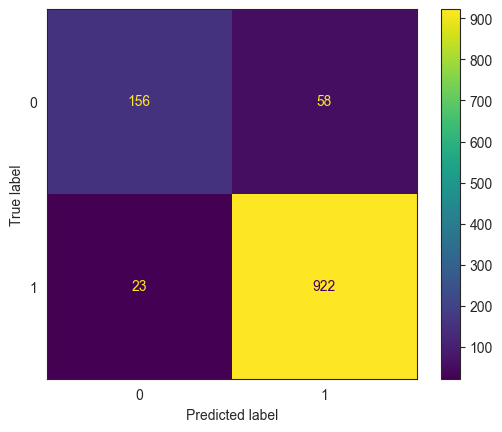

In [37]:
# Count vector:

X_train, X_test, y_train, y_test = train_test_split(X_countvector , y, test_size=0.33, random_state=1)

lr = LogisticRegression()
sns.set_style('white')
pipe_lr = make_pipeline(lr)
pipe_lr.fit(X_train,y_train)
pred = pipe_lr.predict(X_test)
print(classification_report(y_test,pred))
ConfusionMatrixDisplay(confusion_matrix(y_test,pred)).plot()
score_lr = accuracy_score(y_test,pred)

=== Support Vector Machine (SVM) Results ===
              precision    recall  f1-score   support

           0       0.92      0.69      0.79       214
           1       0.93      0.99      0.96       945

    accuracy                           0.93      1159
   macro avg       0.93      0.84      0.87      1159
weighted avg       0.93      0.93      0.93      1159

SVM Accuracy: 0.9318377911993098


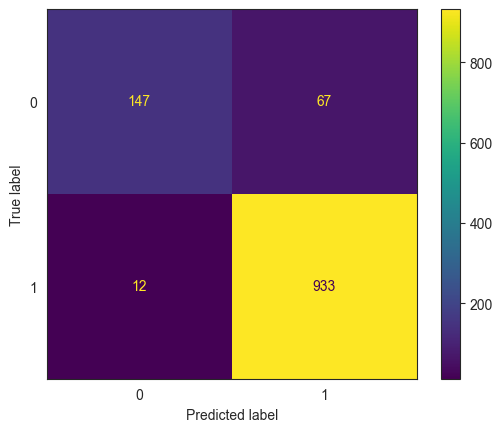

In [38]:
# Train-test split (TF-IDF features)
X_train, X_test, y_train, y_test = train_test_split(X_tf_idf_word, y, test_size=0.33, random_state=1)

# Model
svm = LinearSVC()
svm.fit(X_train, y_train)

# Predictions
y_pred_svm = svm.predict(X_test)

# Evaluation
print("=== Support Vector Machine (SVM) Results ===")
print(classification_report(y_test, y_pred_svm))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_svm)).plot()

# Accuracy
score_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", score_svm)

In [39]:
# Tokenize text
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")  
tokenizer.fit_on_texts(df["Response"])  
X_seq = tokenizer.texts_to_sequences(df["Response"])  

In [40]:
# Padding
X_pad = pad_sequences(X_seq, maxlen=100, padding="post", truncating="post")  

In [41]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.33, random_state=1)

In [42]:
# LSTM Model
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=128))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [43]:
# Train
history = model.fit(X_train, y_train, epochs=3, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.8037 - loss: 0.5276 - val_accuracy: 0.8154 - val_loss: 0.4786
Epoch 2/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.8151 - loss: 0.4754 - val_accuracy: 0.8154 - val_loss: 0.4729
Epoch 3/3
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.8164 - loss: 0.4517 - val_accuracy: 0.8171 - val_loss: 0.4605


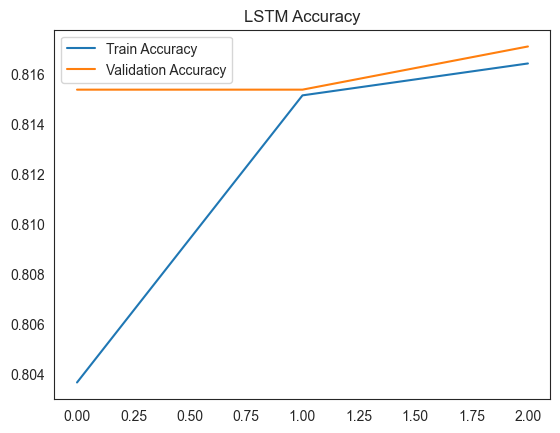

In [44]:
# Training/Validation Curves
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("LSTM Accuracy")
plt.show()

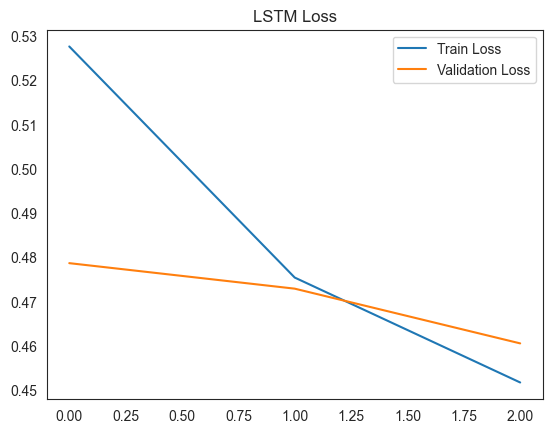

In [45]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("LSTM Loss")
plt.show()

In [46]:
# Predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step


=== LSTM Results ===
              precision    recall  f1-score   support

           0       1.00      0.01      0.02       214
           1       0.82      1.00      0.90       945

    accuracy                           0.82      1159
   macro avg       0.91      0.50      0.46      1159
weighted avg       0.85      0.82      0.74      1159



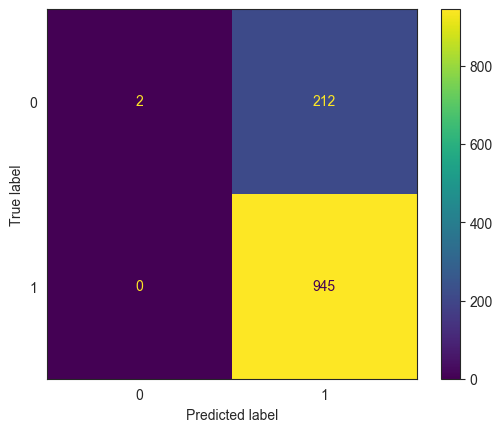

In [47]:
# Evaluation
print("=== LSTM Results ===")
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

In [48]:
# Accuracy
score_lstm = accuracy_score(y_test, y_pred)
print("LSTM Accuracy:", score_lstm)

LSTM Accuracy: 0.817083692838654


In [49]:
#Dataset Class
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
   
    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            return_attention_mask=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }    
    


In [50]:
# Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

In [51]:
# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(df["Response"], y, test_size=0.33, random_state=1)

In [52]:
# Datasets
train_dataset = TextDataset(X_train.tolist(), y_train.tolist(), tokenizer)
test_dataset = TextDataset(X_test.tolist(), y_test.tolist(), tokenizer)

In [53]:
# DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [54]:
# Model & Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)
model.to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [55]:
# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

In [56]:
# Compute Class Weights
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [57]:
# Loss Function with Weights
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

In [58]:
# Training Loop
epochs = 3
train_losses = []

In [59]:
for epoch in range(epochs):
    model.train()
    loop = tqdm(train_loader, leave=True)
    epoch_loss = 0
    
    for batch in loop:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        loop.set_description(f"Epoch {epoch+1}/{epochs}")
        loop.set_postfix(loss=loss.item())

    train_losses.append(epoch_loss / len(train_loader))

Epoch 3/3: 100%|█████████████████████████████████████████████████████████| 148/148 [18:26<00:00,  7.48s/it, loss=0.015]


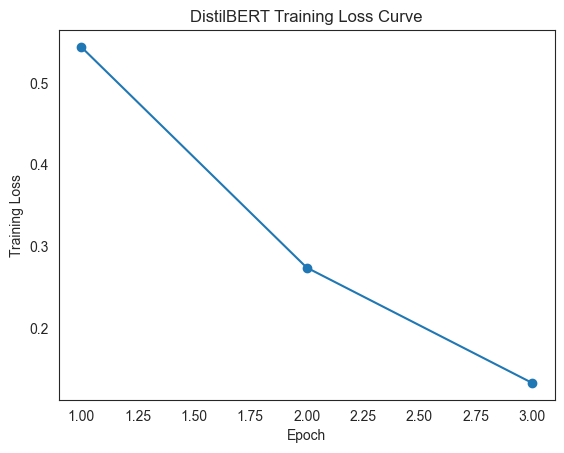

In [60]:
# Plot Training Loss Curve
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("DistilBERT Training Loss Curve")
plt.show()

In [ ]:
# Evaluation
model.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

In [ ]:
# Results
print("=== Improved DistilBERT Results ===")
print(classification_report(y_true, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot()
plt.show()

bert_acc = accuracy_score(y_true, y_pred)
print("DistilBERT Accuracy:", bert_acc)